## Implementing BERT from Scratch for Fake News Classification
 

In [32]:
import math
import copy
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from captum.attr import LayerIntegratedGradients

import warnings
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


---
## Task 1: Implement BERT from Scratch


### 1.1  Multi-Head Self-Attention

In [33]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, (
            f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"
        )

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = math.sqrt(self.head_dim)

        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)

        self.attn_dropout = nn.Dropout(dropout)

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch, seq_len, _ = x.size()
        x = x.view(batch, seq_len, self.num_heads, self.head_dim)
        return x.transpose(1, 2)  

    def merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch, _, seq_len, _ = x.size()
        x = x.transpose(1, 2).contiguous()   
        return x.view(batch, seq_len, self.embed_dim)
    
    def scaled_dot_product_attention(
        self,
        Q: torch.Tensor,
        K: torch.Tensor,
        V: torch.Tensor,
        attention_mask: torch.Tensor = None
    ) -> torch.Tensor:
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if attention_mask is not None:
            scores = scores + attention_mask

        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        context = torch.matmul(attn_weights, V)   
        return context
    
    def forward(
        self,
        x: torch.Tensor,
        attention_mask: torch.Tensor = None
    ) -> torch.Tensor:
        Q = self.split_heads(self.W_q(x))   
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        context = self.scaled_dot_product_attention(Q, K, V, attention_mask)

        context = self.merge_heads(context)  
        output  = self.W_o(context)         
        return output

### 1.2  Position-wise Feed-Forward Network

In [34]:
class FeedForwardLayer(nn.Module):

    def __init__(self, embed_dim: int, ff_dim: int = None, dropout: float = 0.1):
        super().__init__()

        ff_dim = ff_dim if ff_dim is not None else 4 * embed_dim 

        self.linear1   = nn.Linear(embed_dim, ff_dim)   
        self.linear2   = nn.Linear(ff_dim, embed_dim)   
        self.activation = nn.GELU()   
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.linear1(x)   
        x = self.activation(x) 
        x = self.dropout(x)    
        x = self.linear2(x)    
        return x

### 1.3  Transformer Encoder Layer

In [35]:
class TransformerEncoderLayer(nn.Module):

    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        ff_dim: int = None,
        dropout: float = 0.1
    ):
        super().__init__()

        self.attention = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm1     = nn.LayerNorm(embed_dim)
        self.dropout1  = nn.Dropout(dropout)

        self.ffn      = FeedForwardLayer(embed_dim, ff_dim, dropout)
        self.norm2    = nn.LayerNorm(embed_dim)
        self.dropout2 = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        attention_mask: torch.Tensor = None
    ) -> tuple:
        attn_out = self.attention(x, attention_mask)   
        x        = self.norm1(x + self.dropout1(attn_out))

        ffn_out = self.ffn(x)                       
        x       = self.norm2(x + self.dropout2(ffn_out))

        return x, attn_out, ffn_out

### 1.4  BERT Embeddings

In [36]:
class BertEmbeddings(nn.Module):

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        max_position_embeddings: int = 512,
        type_vocab_size: int = 2,
        dropout: float = 0.1
    ):
        super().__init__()

        self.token_embeddings    = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.position_embeddings = nn.Embedding(max_position_embeddings, embed_dim)
        self.token_type_embeddings = nn.Embedding(type_vocab_size, embed_dim)

        self.norm    = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        position_ids = torch.arange(max_position_embeddings).unsqueeze(0)
        self.register_buffer('position_ids', position_ids)

    def forward(
        self,
        input_ids: torch.Tensor,
        token_type_ids: torch.Tensor = None
    ) -> tuple:
        seq_len = input_ids.size(1)

        token_emb = self.token_embeddings(input_ids)           

        positions = self.position_ids[:, :seq_len]             
        pos_emb   = self.position_embeddings(positions)        

        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)        
        type_emb = self.token_type_embeddings(token_type_ids)   

        embeddings = token_emb + pos_emb + type_emb
        embeddings = self.norm(embeddings)
        embeddings = self.dropout(embeddings)

        return embeddings, token_emb, pos_emb

### 1.5  Full BERT Model (Encoder + Pooler + Classifier)

In [37]:
class BertModel(nn.Module):

    def __init__(
        self,
        vocab_size: int               = 30522,
        embed_dim: int                = 512,
        num_heads: int                = 8,
        num_layers: int               = 2,
        ff_dim: int                   = 2048,
        max_position_embeddings: int  = 512,
        type_vocab_size: int          = 2,
        num_classes: int              = 2,
        dropout: float                = 0.1
    ):
        super().__init__()

        self.embeddings = BertEmbeddings(
            vocab_size, embed_dim,
            max_position_embeddings, type_vocab_size, dropout
        )

        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.pooler = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.Tanh()
        )

        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)


    def build_attention_mask(self, attention_mask: torch.Tensor) -> torch.Tensor:
        extended = attention_mask[:, None, None, :]   
        extended = (1.0 - extended.float()) * -1e9  
        return extended


    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        token_type_ids: torch.Tensor = None,
        verbose: bool = False
    ) -> dict:
        embeddings, token_emb, pos_emb = self.embeddings(input_ids, token_type_ids)

        if verbose:
            print("[Embedding Shapes]")
            print(f"  Token Embeddings shape     : {token_emb.shape}")
            print(f"  Positional Embeddings shape: {pos_emb.shape}")
            print(f"  Combined Embeddings shape  : {embeddings.shape}\n")

        ext_mask = (
            self.build_attention_mask(attention_mask)
            if attention_mask is not None else None
        )
        hidden = embeddings
        for idx, layer in enumerate(self.encoder_layers):
            hidden, attn_out, ffn_out = layer(hidden, ext_mask)

            if verbose:
                print(f"[Encoder Layer {idx + 1}]")
                print(f"  MHSA output shape         : {attn_out.shape}")
                print(f"  FFN  output shape         : {ffn_out.shape}")
                print(f"  Encoder Layer output shape: {hidden.shape}")

        if verbose:
            print()

        cls_repr      = hidden[:, 0, :]       
        pooled_output = self.pooler(cls_repr)  

        if verbose:
            print(f"[Pooler (CLS) output shape]   : {pooled_output.shape}")

        logits       = self.classifier(self.dropout(pooled_output))  
        probabilities = F.softmax(logits, dim=-1)                   

        if verbose:
            print(f"[Logits shape]                : {logits.shape}")
            print(f"[Probability output shape]    : {probabilities.shape}")

        return {
            'logits'           : logits,
            'probabilities'    : probabilities,
            'pooled_output'    : pooled_output,
            'last_hidden_state': hidden
        }

### 1.6  Test BERT on a Sample Sentence & Report Shapes

In [38]:

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

SAMPLE_SENTENCE = (
    "The quick brown fox jumps over the lazy dog near the river bank "
    "on a sunny afternoon."
)

print(f"Sample sentence:\n  {SAMPLE_SENTENCE}\n")

encoding = tokenizer(
    SAMPLE_SENTENCE,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=128
)

input_ids      = encoding['input_ids']      
attention_mask = encoding['attention_mask']  

token_type_ids = torch.zeros_like(input_ids)

tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
print(f"Tokens          : {tokens}")
print(f"input_ids shape : {input_ids.shape}")
print(f"attention_mask  : {attention_mask.shape}")
print(f"token_type_ids  : {token_type_ids.shape}")

Sample sentence:
  The quick brown fox jumps over the lazy dog near the river bank on a sunny afternoon.

Tokens          : ['[CLS]', 'the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'near', 'the', 'river', 'bank', 'on', 'a', 'sunny', 'afternoon', '.', '[SEP]']
input_ids shape : torch.Size([1, 20])
attention_mask  : torch.Size([1, 20])
token_type_ids  : torch.Size([1, 20])


In [39]:

bert_scratch = BertModel(
    vocab_size=tokenizer.vocab_size,
    embed_dim=512,
    num_heads=8,
    num_layers=2,
    ff_dim=2048,
    num_classes=2,
    dropout=0.1
)
bert_scratch.eval()  


print("       BERT — EMBEDDING & LAYER SHAPES\n")

with torch.no_grad():
    outputs = bert_scratch(
        input_ids=input_ids,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids,
        verbose=True    
    )

print()
print("       OUTPUT PROBABILITIES\n")
print(f"Logits          : {outputs['logits']}")
print(f"Probabilities   : {outputs['probabilities']}")
print(f"Predicted class : {outputs['probabilities'].argmax(dim=-1).item()}")

       BERT — EMBEDDING & LAYER SHAPES

[Embedding Shapes]
  Token Embeddings shape     : torch.Size([1, 20, 512])
  Positional Embeddings shape: torch.Size([1, 20, 512])
  Combined Embeddings shape  : torch.Size([1, 20, 512])

[Encoder Layer 1]
  MHSA output shape         : torch.Size([1, 20, 512])
  FFN  output shape         : torch.Size([1, 20, 512])
  Encoder Layer output shape: torch.Size([1, 20, 512])
[Encoder Layer 2]
  MHSA output shape         : torch.Size([1, 20, 512])
  FFN  output shape         : torch.Size([1, 20, 512])
  Encoder Layer output shape: torch.Size([1, 20, 512])

[Pooler (CLS) output shape]   : torch.Size([1, 512])
[Logits shape]                : torch.Size([1, 2])
[Probability output shape]    : torch.Size([1, 2])

       OUTPUT PROBABILITIES

Logits          : tensor([[-0.3526, -0.6912]])
Probabilities   : tensor([[0.5838, 0.4162]])
Predicted class : 0


In [40]:

print("       PARAMETER SHAPES — SCRATCH BERT MODEL\n")
print(f"{'Parameter Name':<62} {'Shape':<22} {'# Params':>10}")

total = 0
for name, param in bert_scratch.named_parameters():
    n = param.numel()
    total += n
    print(f"{name:<62} {str(list(param.shape)):<22} {n:>10,}")

print(f"{'TOTAL':62} {'':22} {total:>10,}")

       PARAMETER SHAPES — SCRATCH BERT MODEL

Parameter Name                                                 Shape                    # Params
embeddings.token_embeddings.weight                             [30522, 512]           15,627,264
embeddings.position_embeddings.weight                          [512, 512]                262,144
embeddings.token_type_embeddings.weight                        [2, 512]                    1,024
embeddings.norm.weight                                         [512]                         512
embeddings.norm.bias                                           [512]                         512
encoder_layers.0.attention.W_q.weight                          [512, 512]                262,144
encoder_layers.0.attention.W_q.bias                            [512]                         512
encoder_layers.0.attention.W_k.weight                          [512, 512]                262,144
encoder_layers.0.attention.W_k.bias                            [512]             

In [41]:

batch, seq_len = input_ids.shape
E, H, D = 512, 8, 64 

print("       ANALYTICAL SHAPE SUMMARY (for Report)\n")
print(f"  Batch size                         : {batch}")
print(f"  Sequence length                    : {seq_len}")
print(f"  Embedding dim (E)                  : {E}")
print(f"  Number of heads (H)                : {H}")
print(f"  Per-head dim (d_k = E/H)           : {D}")
print()
print(f"  Token Embeddings                   : ({batch}, {seq_len}, {E})")
print(f"  Positional Embeddings              : (1, {seq_len}, {E})")
print(f"  Combined Embeddings                : ({batch}, {seq_len}, {E})")
print()
print(f"  Q / K / V (per head)               : ({batch}, {H}, {seq_len}, {D})")
print(f"  Attention Scores                   : ({batch}, {H}, {seq_len}, {seq_len})")
print(f"  MHSA output (per encoder layer)    : ({batch}, {seq_len}, {E})")
print(f"  FFN  output (per encoder layer)    : ({batch}, {seq_len}, {E})")
print(f"  Encoder Layer output               : ({batch}, {seq_len}, {E})")
print(f"  Pooler ([CLS]) output              : ({batch}, {E})")
print(f"  Logits                             : ({batch}, 2)")
print(f"  Probabilities                      : ({batch}, 2)")

       ANALYTICAL SHAPE SUMMARY (for Report)

  Batch size                         : 1
  Sequence length                    : 20
  Embedding dim (E)                  : 512
  Number of heads (H)                : 8
  Per-head dim (d_k = E/H)           : 64

  Token Embeddings                   : (1, 20, 512)
  Positional Embeddings              : (1, 20, 512)
  Combined Embeddings                : (1, 20, 512)

  Q / K / V (per head)               : (1, 8, 20, 64)
  Attention Scores                   : (1, 8, 20, 20)
  MHSA output (per encoder layer)    : (1, 20, 512)
  FFN  output (per encoder layer)    : (1, 20, 512)
  Encoder Layer output               : (1, 20, 512)
  Pooler ([CLS]) output              : (1, 512)
  Logits                             : (1, 2)
  Probabilities                      : (1, 2)


---
## Task 2: Data Preprocessing

In [42]:


DATA_DIR = '/kaggle/input/datasets/all-samples'

def load_fakeddit_splits(data_dir: str) -> pd.DataFrame:
    files = ['all_train.tsv', 'all_test_public.tsv', 'all_validate.tsv']
    frames = []
    for fname in files:
        path = os.path.join(data_dir, fname)
        df   = pd.read_csv(path, sep='\t')
        print(f"  Loaded {fname:30s} — {len(df):>7,} rows | columns: {list(df.columns)}")
        frames.append(df)

    combined = pd.concat(frames, ignore_index=True)
    combined = combined[['id', 'clean_title', '2_way_label']].copy()
    return combined


print("Loading Fakeddit splits …")
full_df = load_fakeddit_splits(DATA_DIR)
print(f"\nTotal combined posts : {len(full_df):,}")
print(full_df['2_way_label'].value_counts().rename({0: 'Not Fake (0)', 1: 'Fake (1)'}))
print(full_df.head())

Loading Fakeddit splits …
  Loaded all_train.tsv                  — 878,218 rows | columns: ['Unnamed: 0.2', 'Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.1.1', 'author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']
  Loaded all_test_public.tsv            —  92,444 rows | columns: ['Unnamed: 0.2', 'Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.1.1', 'author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']
  Loaded all_validate.tsv               —  92,444 rows | columns: ['Unnamed: 0.2', 'Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.1.1', 'author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'up

In [43]:

SAMPLES_PER_CLASS = 2500  

def balance_dataset(
    df: pd.DataFrame,
    n: int,
    label_col: str = '2_way_label',
    text_col: str  = 'clean_title',
    seed: int = 42
) -> pd.DataFrame:
    df = df.dropna(subset=[text_col, label_col]).reset_index(drop=True)

    fake_df    = df[df[label_col] == 1]  
    notfake_df = df[df[label_col] == 0] 

    print(f"  Available fake posts    : {len(fake_df):,}")
    print(f"  Available not-fake posts: {len(notfake_df):,}")

    sampled_fake    = fake_df.sample(n=n, random_state=seed)
    sampled_notfake = notfake_df.sample(n=n, random_state=seed)

    balanced = pd.concat([sampled_fake, sampled_notfake], ignore_index=True)
    balanced = balanced.sample(frac=1, random_state=seed).reset_index(drop=True)
    return balanced, fake_df, notfake_df


balanced_df, fake_df_orig, notfake_df_orig = balance_dataset(full_df, SAMPLES_PER_CLASS)

print(f"\nBalanced dataset size    : {len(balanced_df):,}")
print(balanced_df['2_way_label'].value_counts())

  Available fake posts    : 484,721
  Available not-fake posts: 487,085

Balanced dataset size    : 5,000
2_way_label
1    2500
0    2500
Name: count, dtype: int64


In [44]:

def split_dataset(
    df: pd.DataFrame,
    text_col: str = 'clean_title',
    label_col: str = '2_way_label',
    test_size: float = 0.20,
    seed: int = 42
) -> tuple:
    X = df[text_col].values
    y = df[label_col].values

    return train_test_split(
        X, y,
        test_size=test_size,
        random_state=seed,
        stratify=y   
    )


X_train, X_test, y_train, y_test = split_dataset(balanced_df)

print(f"Training samples : {len(X_train):,}")
print(f"  Fake (1)       : {(y_train == 1).sum():,}")
print(f"  Not-fake (0)   : {(y_train == 0).sum():,}")
print(f"\nTest samples     : {len(X_test):,}")
print(f"  Fake (1)       : {(y_test == 1).sum():,}")
print(f"  Not-fake (0)   : {(y_test == 0).sum():,}")

Training samples : 4,000
  Fake (1)       : 2,000
  Not-fake (0)   : 2,000

Test samples     : 1,000
  Fake (1)       : 500
  Not-fake (0)   : 500


In [45]:

print("          DATASET STATISTICS REPORT\n")
print(f"1. Original combined dataset      : {len(full_df):,} posts")
print(f"   Fake posts (label = 1)         : {len(fake_df_orig):,}")
print(f"   Not-fake posts (label = 0)     : {len(notfake_df_orig):,}")
print()
print(f"2. Balanced dataset               : {len(balanced_df):,} posts")
print(f"   Fake posts                     : {SAMPLES_PER_CLASS:,}")
print(f"   Not-fake posts                 : {SAMPLES_PER_CLASS:,}")
print()
print(f"3. Train set                      : {len(X_train):,} posts")
print(f"   Fake                           : {(y_train == 1).sum():,}")
print(f"   Not-fake                       : {(y_train == 0).sum():,}")
print(f"4. Test set                       : {len(X_test):,} posts")
print(f"   Fake                           : {(y_test == 1).sum():,}")
print(f"   Not-fake                       : {(y_test == 0).sum():,}")

          DATASET STATISTICS REPORT

1. Original combined dataset      : 1,063,106 posts
   Fake posts (label = 1)         : 484,721
   Not-fake posts (label = 0)     : 487,085

2. Balanced dataset               : 5,000 posts
   Fake posts                     : 2,500
   Not-fake posts                 : 2,500

3. Train set                      : 4,000 posts
   Fake                           : 2,000
   Not-fake                       : 2,000
4. Test set                       : 1,000 posts
   Fake                           : 500
   Not-fake                       : 500


## Task 3: Fine-tune BERT for Fake News Classification

In [46]:


class FakedditDataset(Dataset):

    def __init__(
        self,
        texts: np.ndarray,
        labels: np.ndarray,
        tokenizer: BertTokenizer,
        max_len: int = 128
    ):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        text  = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',  
            truncation=True,    
            return_tensors='pt'
        )

        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),      
            'attention_mask': encoding['attention_mask'].squeeze(0),  
            'token_type_ids': encoding['token_type_ids'].squeeze(0),  
            'label'         : torch.tensor(label, dtype=torch.long)
        }

In [47]:


MAX_LEN      = 128   
BATCH_SIZE   = 32
EPOCHS       = 3
LR           = 2e-5  
WARMUP_RATIO = 0.1   

print("Hyperparameters:")
print(f"  MAX_LEN      : {MAX_LEN} tokens  "
      f"(truncation: remove trailing tokens beyond position {MAX_LEN})")
print(f"  BATCH_SIZE   : {BATCH_SIZE}")
print(f"  EPOCHS       : {EPOCHS}")
print(f"  LEARNING RATE: {LR}")
print(f"  OPTIMIZER    : AdamW  (weight_decay=0.01 for non-bias params)")
print(f"  SCHEDULER    : Linear warmup ({int(WARMUP_RATIO*100)}%) + linear decay")
print(f"  LOSS         : CrossEntropyLoss")
print(f"  GRAD CLIP    : max_norm = 1.0")

train_dataset = FakedditDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset  = FakedditDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")

Hyperparameters:
  MAX_LEN      : 128 tokens  (truncation: remove trailing tokens beyond position 128)
  BATCH_SIZE   : 32
  EPOCHS       : 3
  LEARNING RATE: 2e-05
  OPTIMIZER    : AdamW  (weight_decay=0.01 for non-bias params)
  SCHEDULER    : Linear warmup (10%) + linear decay
  LOSS         : CrossEntropyLoss
  GRAD CLIP    : max_norm = 1.0

Train batches: 125
Test  batches: 32


In [48]:

bert_finetune = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
).to(device)

no_decay = ['bias', 'LayerNorm.weight']
optimizer_groups = [
    {
        'params': [p for n, p in bert_finetune.named_parameters()
                   if not any(nd in n for nd in no_decay)],
        'weight_decay': 0.01
    },
    {
        'params': [p for n, p in bert_finetune.named_parameters()
                   if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    }
]

optimizer = torch.optim.AdamW(optimizer_groups, lr=LR)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = nn.CrossEntropyLoss()

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps : 375
Warmup steps         : 37


In [49]:


def train_one_epoch(
    model, loader, optimizer, scheduler, criterion, device
) -> tuple:
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(
    model, loader, criterion, device
) -> tuple:
    
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )
            logits = outputs.logits
            loss   = criterion(logits, labels)

            total_loss += loss.item()
            preds       = logits.argmax(dim=-1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        correct / total,
        np.array(all_preds),
        np.array(all_labels)
    )

In [50]:
train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

best_val_acc    = 0.0
best_model_state = None   

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 42)

    tr_loss, tr_acc = train_one_epoch(
        bert_finetune, train_loader, optimizer, scheduler, criterion, device
    )
    val_loss, val_acc, _, _ = evaluate(
        bert_finetune, test_loader, criterion, device
    )

    train_losses.append(tr_loss);  train_accs.append(tr_acc)
    val_losses.append(val_loss);   val_accs.append(val_acc)

    print(f"  Train  Loss: {tr_loss:.4f}  |  Acc: {tr_acc:.4f}")
    print(f"  Val    Loss: {val_loss:.4f}  |  Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc    = val_acc
        best_model_state = copy.deepcopy(bert_finetune.state_dict())
        print(f"  >> New best model (val_acc = {best_val_acc:.4f}) saved.")




Epoch 1/3
------------------------------------------
  Train  Loss: 0.5568  |  Acc: 0.7055
  Val    Loss: 0.4837  |  Acc: 0.7780
  >> New best model (val_acc = 0.7780) saved.

Epoch 2/3
------------------------------------------
  Train  Loss: 0.3732  |  Acc: 0.8430
  Val    Loss: 0.4707  |  Acc: 0.8050
  >> New best model (val_acc = 0.8050) saved.

Epoch 3/3
------------------------------------------
  Train  Loss: 0.2681  |  Acc: 0.9010
  Val    Loss: 0.5018  |  Acc: 0.7940


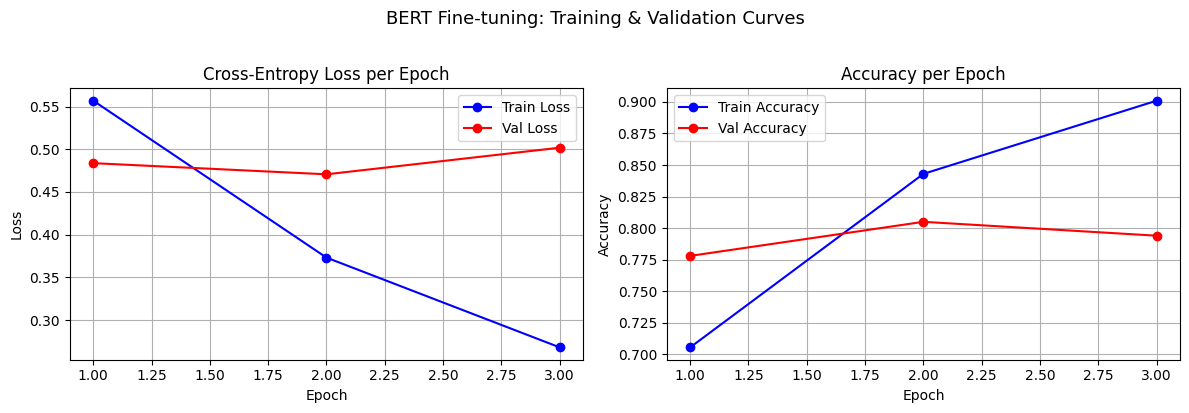

In [51]:
epochs_range = range(1, EPOCHS + 1)
fig, axes    = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_losses, 'b-o', label='Train Loss')
axes[0].plot(epochs_range, val_losses,   'r-o', label='Val Loss')
axes[0].set_title('Cross-Entropy Loss per Epoch')
axes[0].set_xlabel('Epoch');  axes[0].set_ylabel('Loss')
axes[0].legend();             axes[0].grid(True)

axes[1].plot(epochs_range, train_accs, 'b-o', label='Train Accuracy')
axes[1].plot(epochs_range, val_accs,   'r-o', label='Val Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch');  axes[1].set_ylabel('Accuracy')
axes[1].legend();             axes[1].grid(True)

plt.suptitle('BERT Fine-tuning: Training & Validation Curves', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight', dpi=150)
plt.show()


In [52]:
bert_finetune.load_state_dict(best_model_state)
bert_finetune.eval()

_, test_acc, test_preds, test_labels = evaluate(
    bert_finetune, test_loader, criterion, device
)

accuracy  = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds, average='binary')
recall    = recall_score(test_labels,    test_preds, average='binary')
f1        = f1_score(test_labels,        test_preds, average='binary')
cm        = confusion_matrix(test_labels, test_preds)

print("          TEST SET EVALUATION METRICS\n")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print()
print("Full Classification Report:")
print(classification_report(test_labels, test_preds,
                             target_names=['Not Fake', 'Fake']))

          TEST SET EVALUATION METRICS

  Accuracy  : 0.8050
  Precision : 0.8032
  Recall    : 0.8080
  F1-Score  : 0.8056

Full Classification Report:
              precision    recall  f1-score   support

    Not Fake       0.81      0.80      0.80       500
        Fake       0.80      0.81      0.81       500

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.80      1000
weighted avg       0.81      0.81      0.80      1000



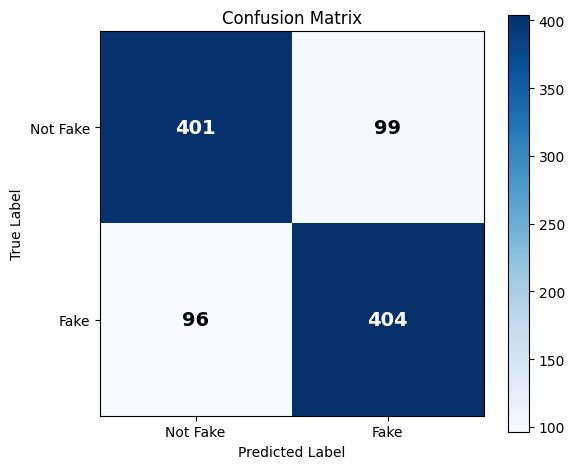

In [53]:

fig, ax = plt.subplots(figsize=(6, 5))
im      = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

class_names = ['Not Fake', 'Fake']
ax.set(xticks=np.arange(2), yticks=np.arange(2),
       xticklabels=class_names, yticklabels=class_names,
       xlabel='Predicted Label', ylabel='True Label',
       title='Confusion Matrix')

thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}",
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [54]:

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value' : [accuracy,    precision,   recall,   f1]
})
metrics_df['Value'] = metrics_df['Value'].round(4)
print(metrics_df.to_string(index=False))

print("\nHyperparameters Used:")
print(f"  Model          : bert-base-uncased (BertForSequenceClassification)")
print(f"  Max Token Len  : {MAX_LEN}  (trailing tokens beyond {MAX_LEN} are removed)")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Learning Rate  : {LR}")
print(f"  Optimizer      : AdamW  (weight_decay = 0.01 for non-bias params)")
print(f"  Scheduler      : Linear warmup ({int(WARMUP_RATIO*100)} %) + linear decay")
print(f"  Loss           : CrossEntropyLoss")
print(f"  Gradient Clip  : max_norm = 1.0")

   Metric  Value
 Accuracy 0.8050
Precision 0.8032
   Recall 0.8080
 F1-Score 0.8056

Hyperparameters Used:
  Model          : bert-base-uncased (BertForSequenceClassification)
  Max Token Len  : 128  (trailing tokens beyond 128 are removed)
  Batch Size     : 32
  Epochs         : 3
  Learning Rate  : 2e-05
  Optimizer      : AdamW  (weight_decay = 0.01 for non-bias params)
  Scheduler      : Linear warmup (10 %) + linear decay
  Loss           : CrossEntropyLoss
  Gradient Clip  : max_norm = 1.0


---
## Task 4: Integrated Gradients for Token Attribution

In [55]:

bert_finetune.load_state_dict(best_model_state)
bert_finetune.eval()
bert_finetune = bert_finetune.to(device)

test_df_final = pd.DataFrame({'text': X_test, 'label': y_test})

fake_idxs    = test_df_final[test_df_final['label'] == 1].index.tolist()[:3]
notfake_idxs = test_df_final[test_df_final['label'] == 0].index.tolist()[:3]

ig_examples = []
for idx in fake_idxs:
    ig_examples.append({'text': test_df_final.loc[idx, 'text'],
                         'label': 1, 'label_name': 'FAKE'})
for idx in notfake_idxs:
    ig_examples.append({'text': test_df_final.loc[idx, 'text'],
                         'label': 0, 'label_name': 'NOT FAKE'})

print("Selected examples for Integrated Gradients analysis:\n")
for i, ex in enumerate(ig_examples):
    print(f"{i+1}. [{ex['label_name']:8s}] {ex['text']}")

Selected examples for Integrated Gradients analysis:

1. [FAKE    ] santa claus runs for north pole city council seat
2. [FAKE    ] focused puppy
3. [FAKE    ] india is introducing free health care for million of the countrys poorest people
4. [NOT FAKE] just horsing around
5. [NOT FAKE] police carries a police
6. [NOT FAKE] the kekistani massacre


In [56]:

def ig_forward_func(
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    token_type_ids: torch.Tensor
) -> torch.Tensor:
    output = bert_finetune(
        input_ids=input_ids,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids
    )
    return output.logits

lig = LayerIntegratedGradients(
    forward_func=ig_forward_func,
    layer=bert_finetune.bert.embeddings.word_embeddings 
)

print("LayerIntegratedGradients initialised.")
print(f"  Attribution layer : bert.bert.embeddings.word_embeddings")
print(f"  Baseline          : all-zero token ids  (≈ [PAD] embedding)")

LayerIntegratedGradients initialised.
  Attribution layer : bert.bert.embeddings.word_embeddings
  Baseline          : all-zero token ids  (≈ [PAD] embedding)


In [57]:

def compute_token_attributions(
    text: str,
    true_label: int,
    target_class: int,
    n_steps: int = 50
) -> dict:
    
    encoding = tokenizer(
        text,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)     
    attention_mask = encoding['attention_mask'].to(device) 
    token_type_ids = encoding['token_type_ids'].to(device)  

    baseline_ids = torch.zeros_like(input_ids)

    with torch.no_grad():
        out = bert_finetune(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
    predicted_class = out.logits.argmax(dim=-1).item()

    attributions, delta = lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(attention_mask, token_type_ids),
        target=target_class,               
        n_steps=n_steps,
        return_convergence_delta=True
    ) 

    attr_scores = attributions.squeeze(0).norm(dim=-1).detach().cpu().numpy()

    a_min, a_max = attr_scores.min(), attr_scores.max()
    if (a_max - a_min) > 1e-8:
        attr_scores = (attr_scores - a_min) / (a_max - a_min)

    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().tolist())

    return {
        'tokens'           : tokens,
        'attributions'     : attr_scores,
        'convergence_delta': delta.item(),
        'predicted_class'  : predicted_class,
        'true_label'       : true_label
    }

N_STEPS    = 50
ig_results = []

for ex in ig_examples:
    print(f"Processing [{ex['label_name']:8s}]: {ex['text'][:70]}…")
    result = compute_token_attributions(
        text=ex['text'],
        true_label=ex['label'],
        target_class=ex['label'],  
        n_steps=N_STEPS
    )
    result['label_name'] = ex['label_name']
    result['text']       = ex['text']
    ig_results.append(result)

    pred_str = 'FAKE' if result['predicted_class'] == 1 else 'NOT FAKE'
    print(f"  Convergence delta: {result['convergence_delta']:.6f}  "
          f"| Predicted: {pred_str}")

print("\nIG computation complete.")

Processing [FAKE    ]: santa claus runs for north pole city council seat…
  Convergence delta: -1.896660  | Predicted: FAKE
Processing [FAKE    ]: focused puppy…
  Convergence delta: 2.279569  | Predicted: NOT FAKE
Processing [FAKE    ]: india is introducing free health care for million of the countrys poor…
  Convergence delta: -0.096255  | Predicted: FAKE
Processing [NOT FAKE]: just horsing around…
  Convergence delta: -0.577182  | Predicted: NOT FAKE
Processing [NOT FAKE]: police carries a police…
  Convergence delta: -1.285946  | Predicted: NOT FAKE
Processing [NOT FAKE]: the kekistani massacre…
  Convergence delta: -0.035311  | Predicted: NOT FAKE

IG computation complete.


In [58]:

SPECIAL_TOKENS = {'[CLS]', '[SEP]', '[PAD]'}


def get_top5_tokens(result: dict) -> list:
    filtered = [
        (tok, score)
        for tok, score in zip(result['tokens'], result['attributions'])
        if tok not in SPECIAL_TOKENS
    ]
    return sorted(filtered, key=lambda x: x[1], reverse=True)[:5]


print("          TOP-5 ATTRIBUTED TOKENS PER EXAMPLE\n")

for i, result in enumerate(ig_results):
    top5 = get_top5_tokens(result)
    pred_str = 'FAKE' if result['predicted_class'] == 1 else 'NOT FAKE'

    print(f"\nExample {i+1}: [{result['label_name']}]")
    print(f"  Text               : {result['text']}")
    print(f"  Target class index : {result['true_label']}  "
          f"({result['label_name']})")
    print(f"  Predicted          : {pred_str}")
    print(f"  Convergence delta  : {result['convergence_delta']:.6f}")
    print(f"  Top-5 tokens:")
    for rank, (tok, score) in enumerate(top5, 1):
        print(f"    {rank}. '{tok}'  → {score:.4f}")

          TOP-5 ATTRIBUTED TOKENS PER EXAMPLE


Example 1: [FAKE]
  Text               : santa claus runs for north pole city council seat
  Target class index : 1  (FAKE)
  Predicted          : FAKE
  Convergence delta  : -1.896660
  Top-5 tokens:
    1. 'claus'  → 0.3645
    2. 'city'  → 0.3471
    3. 'pole'  → 0.3239
    4. 'seat'  → 0.3101
    5. 'runs'  → 0.2867

Example 2: [FAKE]
  Text               : focused puppy
  Target class index : 1  (FAKE)
  Predicted          : NOT FAKE
  Convergence delta  : 2.279569
  Top-5 tokens:
    1. 'puppy'  → 0.3880
    2. 'focused'  → 0.2466

Example 3: [FAKE]
  Text               : india is introducing free health care for million of the countrys poorest people
  Target class index : 1  (FAKE)
  Predicted          : FAKE
  Convergence delta  : -0.096255
  Top-5 tokens:
    1. 'india'  → 0.9244
    2. 'health'  → 0.6900
    3. 'introducing'  → 0.6729
    4. 'country'  → 0.6025
    5. 'care'  → 0.5910

Example 4: [NOT FAKE]
  Text              

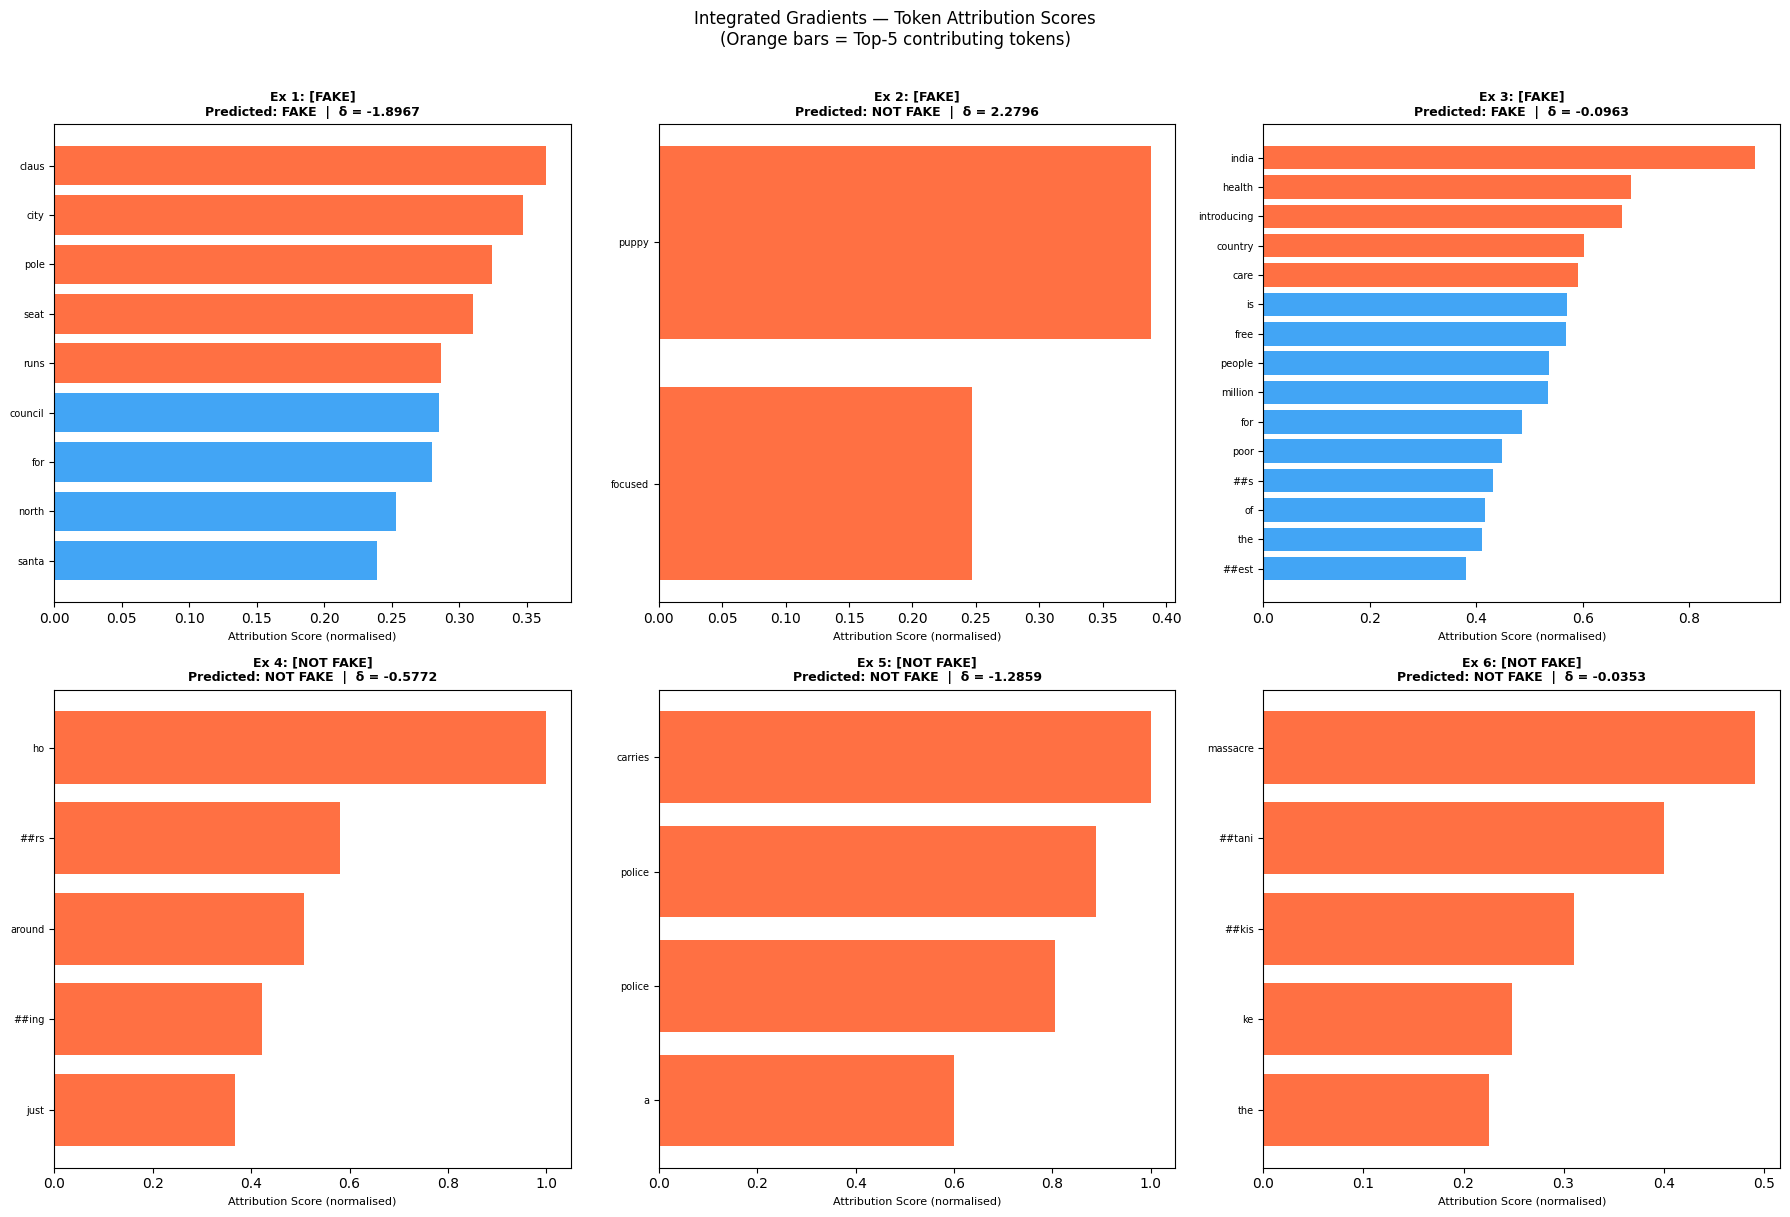

In [59]:

def plot_attribution_bar(result: dict, ax, title: str) -> None:
    pairs = [
        (tok, score)
        for tok, score in zip(result['tokens'], result['attributions'])
        if tok not in SPECIAL_TOKENS
    ]

    pairs = sorted(pairs, key=lambda x: x[1])
    f_tokens = [p[0] for p in pairs]
    f_scores = [p[1] for p in pairs]

    top5_threshold = sorted(f_scores, reverse=True)[min(4, len(f_scores) - 1)]
    colors = ['#FF7043' if s >= top5_threshold else '#42A5F5' for s in f_scores]

    ax.barh(range(len(f_tokens)), f_scores, color=colors)
    ax.set_yticks(range(len(f_tokens)))
    ax.set_yticklabels(f_tokens, fontsize=7)
    ax.set_xlabel('Attribution Score (normalised)', fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes_flat = axes.flatten()

for i, result in enumerate(ig_results):
    pred_str = 'FAKE' if result['predicted_class'] == 1 else 'NOT FAKE'
    chart_title = (
        f"Ex {i+1}: [{result['label_name']}]\n"
        f"Predicted: {pred_str}  |  δ = {result['convergence_delta']:.4f}"
    )
    plot_attribution_bar(result, axes_flat[i], chart_title)

plt.suptitle(
    'Integrated Gradients — Token Attribution Scores\n'
    '(Orange bars = Top-5 contributing tokens)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('integrated_gradients_attribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [60]:

print("          INTEGRATED GRADIENTS SUMMARY  (for Report)\n")
print(f"  Method              : LayerIntegratedGradients (Captum)")
print(f"  Attribution layer   : bert.embeddings.word_embeddings")
print(f"  Baseline            : All-zero token ids  (PAD embedding ≈ 0)")
print(f"  Target class        : True label of each example")
print(f"  n_steps             : {N_STEPS}")
print(f"  Aggregation         : L2-norm across embedding dimension")
print(f"  Normalisation       : Min-max to [0, 1]")
print(f"  Excluded tokens     : [CLS], [SEP], [PAD]")
print("-" * 72)

for i, result in enumerate(ig_results):
    top5     = get_top5_tokens(result)
    top5_str = ', '.join([f"'{t}' ({s:.3f})" for t, s in top5])
    pred_str = 'FAKE' if result['predicted_class'] == 1 else 'NOT FAKE'

    print(f"\nEx {i+1} [{result['label_name']}]:")
    print(f"  Text              : {result['text']}")
    print(f"  Target class      : {result['true_label']} | Predicted: {result['predicted_class']} ({pred_str})")
    print(f"  Convergence delta : {result['convergence_delta']:.6f}")
    print(f"  Top-5 tokens      : {top5_str}")

          INTEGRATED GRADIENTS SUMMARY  (for Report)

  Method              : LayerIntegratedGradients (Captum)
  Attribution layer   : bert.embeddings.word_embeddings
  Baseline            : All-zero token ids  (PAD embedding ≈ 0)
  Target class        : True label of each example
  n_steps             : 50
  Aggregation         : L2-norm across embedding dimension
  Normalisation       : Min-max to [0, 1]
  Excluded tokens     : [CLS], [SEP], [PAD]
------------------------------------------------------------------------

Ex 1 [FAKE]:
  Text              : santa claus runs for north pole city council seat
  Target class      : 1 | Predicted: 1 (FAKE)
  Convergence delta : -1.896660
  Top-5 tokens      : 'claus' (0.364), 'city' (0.347), 'pole' (0.324), 'seat' (0.310), 'runs' (0.287)

Ex 2 [FAKE]:
  Text              : focused puppy
  Target class      : 1 | Predicted: 0 (NOT FAKE)
  Convergence delta : 2.279569
  Top-5 tokens      : 'puppy' (0.388), 'focused' (0.247)

Ex 3 [FAKE]:
  Te